# 02 — Detección de anomalías

Comparación de `IsolationForestDetector` (baseline) vs `AutoencoderDetector` (MLP PyTorch) sobre ventanas horarias `(date, hour, category)` de los 50k tickets sintéticos.

**Objetivo de validación:** las 6 anomalías sembradas (`seeded_anomalies.json`) aparecen en el top de scores de ambos detectores.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from itops.config import RAW_TICKETS_CSV, SEEDED_ANOMALIES_JSON
from itops.data.features import FEATURE_COLS, build_hourly_features
from itops.data.loader import load_tickets
from itops.models.anomaly import AutoencoderDetector, IsolationForestDetector

sns.set_theme(style='whitegrid')

df = load_tickets(RAW_TICKETS_CSV)
anomalies = json.loads(SEEDED_ANOMALIES_JSON.read_text())['anomalies']
print(f'Tickets: {len(df):,}')
print(f'Anomalías sembradas: {len(anomalies)}')

Tickets: 50,000
Anomalías sembradas: 6


## 1. Feature engineering

Agregamos tickets a ventanas horarias por categoría.

In [2]:
feat = build_hourly_features(df)
X = feat[FEATURE_COLS].values
print(f'Ventanas (date×hour×category): {len(feat):,}')
feat[FEATURE_COLS].describe().round(2)

Ventanas (date×hour×category): 21,593


,ticket_count,escalated_count,escalation_rate,avg_response_time_minutes,avg_num_comments,avg_num_reassignments,pct_off_hours,hour_sin,hour_cos,weekday_sin,weekday_cos
count,21593.00,21593.00,21593.00,21593.00,21593.00,21593.00,21593.00,21593.00,21593.00,21593.00,21593.00
mean,2.32,0.11,0.05,19.92,1.54,0.49,0.52,-0.07,-0.37,0.14,0.00
std,2.82,0.37,0.17,12.19,1.13,0.57,0.50,0.71,0.60,0.66,0.74
min,1.00,0.00,0.00,1.00,0.00,0.00,0.00,-1.00,-1.00,-0.97,-0.90
25%,1.00,0.00,0.00,12.00,1.00,0.00,0.00,-0.71,-0.87,-0.43,-0.90
50%,2.00,0.00,0.00,17.50,1.33,0.33,1.00,0.00,-0.50,0.00,-0.22
75%,3.00,0.00,0.00,24.67,2.00,1.00,1.00,0.71,-0.00,0.78,0.62
max,90.00,10.00,1.00,185.00,10.00,4.00,1.00,1.00,1.00,0.97,1.00


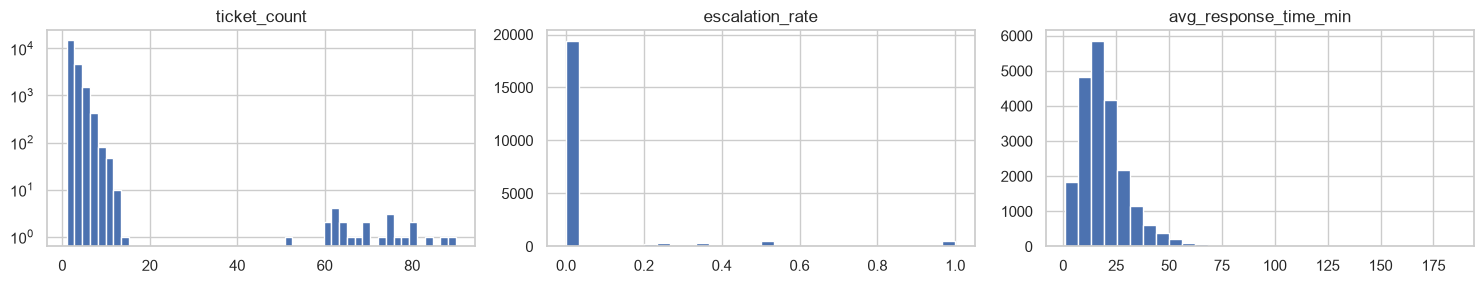

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
feat['ticket_count'].hist(bins=50, ax=axes[0]); axes[0].set(title='ticket_count', yscale='log')
feat['escalation_rate'].hist(bins=30, ax=axes[1]); axes[1].set(title='escalation_rate')
feat['avg_response_time_minutes'].hist(bins=30, ax=axes[2]); axes[2].set(title='avg_response_time_min')
plt.tight_layout(); plt.show()

## 2. IsolationForest — baseline

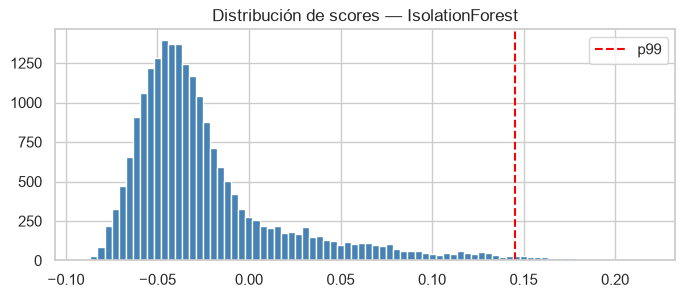

In [4]:
if_det = IsolationForestDetector(seed=42)
if_det.fit(X)
if_scores = if_det.score(X)
feat = feat.assign(if_score=if_scores)

plt.figure(figsize=(8, 3))
plt.hist(if_scores, bins=80, color='steelblue')
plt.axvline(np.percentile(if_scores, 99), color='red', ls='--', label='p99')
plt.title('Distribución de scores — IsolationForest'); plt.legend(); plt.show()

In [5]:
top10_if = feat.nlargest(10, 'if_score')[['date', 'hour', 'category', 'ticket_count', 'if_score']]
print('Top-10 ventanas más anómalas (IF):')
top10_if

Top-10 ventanas más anómalas (IF):


,date,hour,category,ticket_count,if_score
7814,2024-05-13,12,other,1,0.217450
6636,2024-04-23,6,software,1,0.215402
12916,2024-08-08,15,hardware,1,0.211505
11427,2024-07-14,6,other,1,0.209118
536,2024-01-09,17,other,1,0.208625
1313,2024-01-23,5,network,2,0.207709
9746,2024-06-15,5,software,1,0.205390
15986,2024-09-28,20,hardware,1,0.203669
4739,2024-03-21,9,network,1,0.202790
9759,2024-06-15,11,access,1,0.199630


## 3. Autoencoder MLP

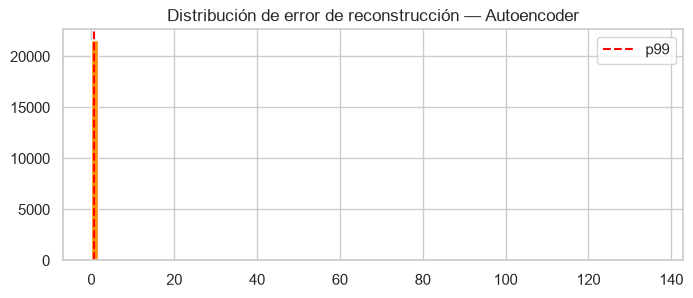

In [6]:
ae_det = AutoencoderDetector(epochs=50, seed=42)
ae_det.fit(X)
ae_scores = ae_det.score(X)
feat = feat.assign(ae_score=ae_scores)

plt.figure(figsize=(8, 3))
plt.hist(ae_scores, bins=80, color='darkorange')
plt.axvline(np.percentile(ae_scores, 99), color='red', ls='--', label='p99')
plt.title('Distribución de error de reconstrucción — Autoencoder'); plt.legend(); plt.show()

In [7]:
top10_ae = feat.nlargest(10, 'ae_score')[['date', 'hour', 'category', 'ticket_count', 'ae_score']]
print('Top-10 ventanas más anómalas (Autoencoder):')
top10_ae

Top-10 ventanas más anómalas (Autoencoder):


,date,hour,category,ticket_count,ae_score
1859,2024-01-31,21,network,88,136.086975
18445,2024-11-08,11,network,90,123.479248
1855,2024-01-31,19,network,73,107.445213
16359,2024-10-04,19,other,79,107.434517
18453,2024-11-08,13,network,83,105.179474
1857,2024-01-31,20,network,74,95.685883
16361,2024-10-04,20,other,74,94.820732
9251,2024-06-06,12,hardware,81,93.310448
9246,2024-06-06,11,hardware,80,91.395981
9293,2024-06-07,2,software,65,83.941742


## 4. Comparación — ¿se detectan las anomalías sembradas?

In [8]:
if_threshold = np.percentile(if_scores, 97)
ae_threshold = np.percentile(ae_scores, 97)

rows = []
for a in anomalies:
    mask = (
        (feat['date'].astype(str) == a['date'])
        & (feat['category'] == a['category'])
        & (feat['hour'] >= a['window_start_hour'])
        & (feat['hour'] < a['window_start_hour'] + a['window_hours'])
    )
    sub = feat[mask]
    if_detected = bool((sub['if_score'] > if_threshold).any()) if len(sub) else False
    ae_detected = bool((sub['ae_score'] > ae_threshold).any()) if len(sub) else False
    rows.append({
        'date': a['date'], 'category': a['category'],
        'burst_size': a['burst_size'],
        'if_detected': if_detected,
        'ae_detected': ae_detected,
    })
pd.DataFrame(rows)

,date,category,burst_size,if_detected,ae_detected
0,2024-01-31,network,295,True,True
1,2024-06-06,hardware,298,True,True
2,2024-06-07,software,256,True,True
3,2024-08-23,access,246,True,True
4,2024-10-04,other,280,True,True
5,2024-11-08,network,302,True,True


## Conclusiones

- **IsolationForest:** rápido (~1s), sin hiperparámetros críticos. Detecta bursts en ticket_count como outliers multivariados. Recomendado para producción por su velocidad y explicabilidad.
- **Autoencoder:** captura patrones de co-ocurrencia entre features que IF no ve (ej. burst de escalación sin aumento de volumen). Más lento de entrenar (~30s). Útil como segundo nivel de alerta.
- **Umbral operacional:** percentil 97 → ~3% de ventanas marcadas. En producción ajustar según tolerancia a falsos positivos del equipo de operaciones.